# Logistic Regression 모델링

대학생 중도이탈(Dropout) 예측을 위한 Logistic Regression 모델

- Target
  - 1: Dropout
  - 0: Non-Dropout (Graduate + Enrolled)
- 전처리: preprocess.ipynb 결과 사용
- 평가 데이터: train / validation / test

In [2]:
# ============================================
# 1. 필요한 라이브러리 불러오기
# ============================================

# 데이터 처리를 위한 라이브러리
import pandas as pd
import numpy as np

# Logistic Regression 모델
from sklearn.linear_model import LogisticRegression

# 모델 성능 평가 지표
from sklearn.metrics import (
    accuracy_score,        # 정확도
    precision_score,       # 정밀도
    recall_score,          # 재현율
    f1_score,              # F1-score
    roc_auc_score,         # ROC-AUC
    confusion_matrix,      # 혼동행렬
    classification_report  # 주요 평가지표 종합 출력
)

# 학습한 모델을 파일(.joblib)로 저장하기 위한 라이브러리
import joblib

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [3]:
# ============================================
# 2. 전처리된 데이터 불러오기
# ============================================

# preprocess.ipynb에서 이미 전처리가 완료된 데이터를 사용
# 따라서 이 노트북에서는 One-Hot Encoding, Scaling 등을 다시 수행하지 않음

train = pd.read_csv("../data/processed/train.csv")
val = pd.read_csv("../data/processed/val.csv")
test = pd.read_csv("../data/processed/test.csv")

# 각 데이터셋의 행(row), 열(column) 개수 확인
print("Train 데이터 크기 :", train.shape)
print("Validation 데이터 크기 :", val.shape)
print("Test 데이터 크기 :", test.shape)

Train 데이터 크기 : (2654, 82)
Validation 데이터 크기 : (885, 82)
Test 데이터 크기 : (885, 82)


In [4]:
# ============================================
# 3. Feature(X)와 Target(y) 분리
# ============================================

# 'target'을 제외한 나머지 컬럼 → 모델이 학습할 Feature(X)
X_train = train.drop(columns="target")
X_val = val.drop(columns="target")
X_test = test.drop(columns="target")

# 'target' 컬럼 → 모델이 맞혀야 하는 정답(y)
# 0 : Non-Dropout (Graduate + Enrolled)
# 1 : Dropout
y_train = train["target"]
y_val = val["target"]
y_test = test["target"]

# 데이터 크기 확인
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_val   :", X_val.shape)
print("y_val   :", y_val.shape)

print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

X_train : (2654, 81)
y_train : (2654,)
X_val   : (885, 81)
y_val   : (885,)
X_test  : (885, 81)
y_test  : (885,)


In [5]:
# ============================================
# 4. Target 클래스 분포 확인
# ============================================

# 학습 데이터에서 각 클래스의 실제 개수 확인
print("Target 개수")
print(y_train.value_counts())

print("\nTarget 비율")
print(y_train.value_counts(normalize=True))

Target 개수
target
0    1802
1     852
Name: count, dtype: int64

Target 비율
target
0    0.678975
1    0.321025
Name: proportion, dtype: float64


In [6]:
# ============================================
# 5. Logistic Regression 모델 생성
# ============================================

# Logistic Regression
# → 학생의 여러 Feature를 이용하여
#   Dropout(1) / Non-Dropout(0)을 예측하는 이진 분류 모델

model = LogisticRegression(
    
    # 모델 학습 시 최대 반복 횟수
    # 기본 반복 횟수보다 넉넉하게 설정하여 수렴 문제를 방지
    max_iter=1000,
    
    # 실행할 때마다 동일한 결과를 재현하기 위한 설정
    random_state=42
)

print("Logistic Regression 모델 생성 완료!")

Logistic Regression 모델 생성 완료!


In [7]:
# ============================================
# 6. Logistic Regression 모델 학습
# ============================================

# X_train : 학생들의 Feature
# y_train : 실제 Dropout 여부
#
# 모델이 X_train과 y_train 사이의 관계를 학습함

# 끝에 세미콜론(;)을 사용하여
# Jupyter Notebook에서 sklearn 모델을 HTML로 출력하면서 발생했던
# Windows cp949 UnicodeDecodeError를 방지
model.fit(X_train, y_train);

print("Logistic Regression 학습 완료!")


Logistic Regression 학습 완료!


In [8]:
# ============================================
# 7. 모델 학습 완료 여부 확인
# ============================================

# Logistic Regression이 정상적으로 학습되면
# 각 Feature에 대한 가중치(coef_)가 생성됨

print("학습 완료 여부 :", hasattr(model, "coef_"))

# 가중치 배열의 크기 확인
print("모델 가중치 크기 :", model.coef_.shape)

학습 완료 여부 : True
모델 가중치 크기 : (1, 81)


In [9]:
# ============================================
# 8. Validation 데이터 예측
# ============================================

# Validation 데이터의 최종 클래스 예측
#
# 결과:
# 0 → Non-Dropout
# 1 → Dropout
y_val_pred = model.predict(X_val)


# 각 학생이 Dropout(1)일 확률 계산
#
# predict_proba()는
# [0일 확률, 1일 확률]을 반환하기 때문에
# [:, 1]을 사용하여 Dropout(1)의 확률만 가져옴
#
# 이 값은 이후 ROC-AUC 계산에 사용
y_val_proba = model.predict_proba(X_val)[:, 1]

print("Validation 데이터 예측 완료!")

Validation 데이터 예측 완료!


In [10]:
# ============================================
# 9. Validation 데이터 모델 성능 평가
# ============================================

# Accuracy (정확도)
# → 전체 학생 중 모델이 올바르게 예측한 학생의 비율
accuracy = accuracy_score(y_val, y_val_pred)

# Precision (정밀도)
# → 모델이 Dropout이라고 예측한 학생 중
#   실제 Dropout 학생의 비율
precision = precision_score(y_val, y_val_pred)

# Recall (재현율)
# → 실제 Dropout 학생 중
#   모델이 Dropout이라고 찾아낸 학생의 비율
recall = recall_score(y_val, y_val_pred)

# F1-score
# → Precision과 Recall의 균형을 나타내는 지표
f1 = f1_score(y_val, y_val_pred)

# ROC-AUC
# → 모델이 Dropout과 Non-Dropout을
#   얼마나 잘 구분하는지를 나타내는 지표
roc_auc = roc_auc_score(y_val, y_val_proba)


# 평가 결과 출력
print("===== Logistic Regression Validation 성능 =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

===== Logistic Regression Validation 성능 =====
Accuracy  : 0.8859
Precision : 0.8651
Recall    : 0.7649
F1-score  : 0.8119
ROC-AUC   : 0.9243


In [11]:
# ============================================
# 10. 모델 평가 결과 CSV 저장
# ============================================

import os

# 이번 Logistic Regression의 평가 결과를
# 한 행(row)의 DataFrame으로 생성
result = pd.DataFrame({
    "model": ["Logistic Regression"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1_score": [f1],
    "roc_auc": [roc_auc]
})


# 저장할 파일 경로
result_path = "../reports/model_results.csv"


# model_results.csv가 이미 존재하는지 확인
if os.path.exists(result_path):

    # 기존 결과 불러오기
    existing_results = pd.read_csv(result_path)

    # 같은 Logistic Regression 결과가 이미 있다면 제거
    # → 노트북을 여러 번 실행했을 때 중복 저장되는 것을 방지
    existing_results = existing_results[
        existing_results["model"] != "Logistic Regression"
    ]

    # 기존 모델 결과 + Logistic Regression 결과 합치기
    model_results = pd.concat(
        [existing_results, result],
        ignore_index=True
    )

else:
    # 파일이 없다면 Logistic Regression 결과로 새로 생성
    model_results = result


# CSV 파일로 저장
model_results.to_csv(
    result_path,
    index=False
)

print("모델 평가 결과 저장 완료!")
print(f"저장 위치: {result_path}")

# 현재 저장된 전체 모델 결과 확인
model_results

모델 평가 결과 저장 완료!
저장 위치: ../reports/model_results.csv


,model,accuracy,precision,recall,f1_score,roc_auc,dataset,threshold
0,Random Forest,0.891525,0.845588,0.809859,0.827338,0.934856,test,0.55
1,Logistic Regression,0.885876,0.865079,0.764912,0.811918,0.924292,NaN,NaN


In [12]:
# ============================================
# 11. Validation 데이터 Confusion Matrix 확인
# ============================================

# 실제값(y_val)과 예측값(y_val_pred)을 비교하여
# 혼동행렬(Confusion Matrix) 생성
cm = confusion_matrix(y_val, y_val_pred)

# 혼동행렬 출력
print("===== Confusion Matrix =====")
print(cm)

# 혼동행렬의 4가지 값을 각각 분리
tn, fp, fn, tp = cm.ravel()

print("\n===== 예측 결과 상세 =====")

# TN (True Negative)
# 실제 Non-Dropout(0)을 Non-Dropout(0)으로 정확히 예측
print(f"TN - 정확히 Non-Dropout 예측 : {tn}명")

# FP (False Positive)
# 실제 Non-Dropout(0)인데 Dropout(1)으로 잘못 예측
print(f"FP - 잘못 Dropout으로 예측   : {fp}명")

# FN (False Negative)
# 실제 Dropout(1)인데 Non-Dropout(0)으로 잘못 예측
# 중도이탈 학생을 놓친 경우이므로 프로젝트에서 중요하게 확인
print(f"FN - 놓친 Dropout 학생       : {fn}명")

# TP (True Positive)
# 실제 Dropout(1)을 Dropout(1)으로 정확히 예측
print(f"TP - 정확히 찾은 Dropout 학생 : {tp}명")

===== Confusion Matrix =====
[[566  34]
 [ 67 218]]

===== 예측 결과 상세 =====
TN - 정확히 Non-Dropout 예측 : 566명
FP - 잘못 Dropout으로 예측   : 34명
FN - 놓친 Dropout 학생       : 67명
TP - 정확히 찾은 Dropout 학생 : 218명


In [13]:
# ============================================
# 12. Validation 데이터 Classification Report 확인
# ============================================

# Classification Report를 통해 클래스별
# Precision, Recall, F1-score를 한 번에 확인
#
# 0 : Non-Dropout (Graduate + Enrolled)
# 1 : Dropout
#
# 특히 이번 프로젝트에서는
# Dropout(1)의 Recall과 F1-score를 중요하게 확인
report = classification_report(
    y_val,
    y_val_pred,
    target_names=["Non-Dropout", "Dropout"]
)

print("===== Classification Report =====")
print(report)

===== Classification Report =====
              precision    recall  f1-score   support

 Non-Dropout       0.89      0.94      0.92       600
     Dropout       0.87      0.76      0.81       285

    accuracy                           0.89       885
   macro avg       0.88      0.85      0.87       885
weighted avg       0.88      0.89      0.88       885



In [14]:
# ============================================
# 13. class_weight="balanced" 모델 학습 및 비교
# ============================================

# 기존 Logistic Regression은 모든 클래스에 동일한 가중치를 적용했음
#
# 하지만 현재 학습 데이터는
# Non-Dropout(0) : 약 67.9%
# Dropout(1)     : 약 32.1%
# 로 클래스 비율에 차이가 있음
#
# class_weight="balanced"를 사용하면
# 데이터가 적은 Dropout(1) 클래스에 상대적으로 더 높은 가중치를 부여하여
# 실제 Dropout 학생을 더 잘 찾아내는지 확인할 수 있음

balanced_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

# Balanced Logistic Regression 학습
balanced_model.fit(X_train, y_train);

print("Balanced Logistic Regression 학습 완료!")


# ============================================
# Validation 데이터 예측
# ============================================

# 0 / 1 클래스 예측
y_val_pred_balanced = balanced_model.predict(X_val)

# Dropout(1)일 확률 예측
y_val_proba_balanced = balanced_model.predict_proba(X_val)[:, 1]


# ============================================
# 성능 평가
# ============================================

balanced_accuracy = accuracy_score(
    y_val,
    y_val_pred_balanced
)

balanced_precision = precision_score(
    y_val,
    y_val_pred_balanced
)

balanced_recall = recall_score(
    y_val,
    y_val_pred_balanced
)

balanced_f1 = f1_score(
    y_val,
    y_val_pred_balanced
)

balanced_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_balanced
)


print("\n===== Balanced Logistic Regression Validation 성능 =====")
print(f"Accuracy  : {balanced_accuracy:.4f}")
print(f"Precision : {balanced_precision:.4f}")
print(f"Recall    : {balanced_recall:.4f}")
print(f"F1-score  : {balanced_f1:.4f}")
print(f"ROC-AUC   : {balanced_roc_auc:.4f}")

Balanced Logistic Regression 학습 완료!

===== Balanced Logistic Regression Validation 성능 =====
Accuracy  : 0.8576
Precision : 0.7477
Recall    : 0.8421
F1-score  : 0.7921
ROC-AUC   : 0.9237


In [15]:
# ============================================
# 14. 기본 모델 vs Balanced 모델 성능 비교
# ============================================

# 두 Logistic Regression 모델의 Validation 성능을
# 하나의 DataFrame으로 정리하여 비교

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Balanced)"
    ],
    
    "Accuracy": [
        accuracy,
        balanced_accuracy
    ],
    
    "Precision": [
        precision,
        balanced_precision
    ],
    
    "Recall": [
        recall,
        balanced_recall
    ],
    
    "F1-score": [
        f1,
        balanced_f1
    ],
    
    "ROC-AUC": [
        roc_auc,
        balanced_roc_auc
    ]
})

# 소수점 넷째 자리까지 표시
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8859,0.8651,0.7649,0.8119,0.9243
1,Logistic Regression (Balanced),0.8576,0.7477,0.8421,0.7921,0.9237


### 모델 비교 결과

- 기본 Logistic Regression은 Accuracy, Precision, F1-score에서 더 높은 성능을 보였다.
- `class_weight="balanced"` 적용 모델은 Dropout Recall이 0.7649 → 0.8421로 향상되었다.
- 반면 Precision은 0.8651 → 0.7477로 감소하여, Dropout이 아닌 학생을 위험 학생으로 판단하는 False Positive가 증가할 가능성이 있다.
- ROC-AUC는 0.9243과 0.9237로 두 모델 간 큰 차이가 없었다.
- 따라서 중도이탈 학생 탐지를 우선할 경우 Balanced 모델의 장점이 있으나, 전체적인 성능 균형을 고려하여 추가 비교 후 최종 모델을 선정한다.

In [16]:
# ============================================
# 15. Threshold 조정에 따른 성능 비교
# ============================================

# 기본 Logistic Regression의 기본 threshold는 0.5
# 즉, Dropout 확률이 0.5 이상이면 1(Dropout)로 예측함
#
# 이번에는 threshold를 조금 낮춰서
# 실제 Dropout 학생을 더 많이 찾아낼 수 있는지 확인

thresholds = [0.50, 0.45, 0.40, 0.35]

threshold_results = []

for threshold in thresholds:
    
    # 각 threshold 기준으로 Dropout 여부 예측
    # 확률이 threshold 이상이면 1(Dropout), 아니면 0(Non-Dropout)
    y_val_pred_threshold = (y_val_proba >= threshold).astype(int)

    # 성능 지표 계산
    threshold_accuracy = accuracy_score(
        y_val,
        y_val_pred_threshold
    )

    threshold_precision = precision_score(
        y_val,
        y_val_pred_threshold
    )

    threshold_recall = recall_score(
        y_val,
        y_val_pred_threshold
    )

    threshold_f1 = f1_score(
        y_val,
        y_val_pred_threshold
    )

    # ROC-AUC는 threshold와 무관하게
    # 예측 확률 자체를 이용하므로 동일한 값을 사용
    threshold_roc_auc = roc_auc_score(
        y_val,
        y_val_proba
    )

    # 결과 저장
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": threshold_accuracy,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1-score": threshold_f1,
        "ROC-AUC": threshold_roc_auc
    })


# 결과를 DataFrame으로 변환
threshold_comparison = pd.DataFrame(threshold_results)

# 소수점 넷째 자리까지 출력
threshold_comparison.round(4)

,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.50,0.8859,0.8651,0.7649,0.8119,0.9243
1,0.45,0.8814,0.8383,0.7825,0.8094,0.9243
2,0.40,0.8791,0.8134,0.8105,0.8120,0.9243
3,0.35,0.8678,0.7727,0.8351,0.8027,0.9243


In [17]:
# ============================================
# 16. 기본 / Balanced / Threshold 조정 모델 비교
# ============================================

# threshold 비교 결과에 모델 이름 추가
threshold_model_results = threshold_comparison.copy()

threshold_model_results["Model"] = (
    "Logistic Regression (Threshold="
    + threshold_model_results["Threshold"].astype(str)
    + ")"
)

# 비교에 필요한 컬럼만 선택
threshold_model_results = threshold_model_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ]
]


# 기본 모델 결과
base_result = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc]
})


# Balanced 모델 결과
balanced_result = pd.DataFrame({
    "Model": ["Logistic Regression (Balanced)"],
    "Accuracy": [balanced_accuracy],
    "Precision": [balanced_precision],
    "Recall": [balanced_recall],
    "F1-score": [balanced_f1],
    "ROC-AUC": [balanced_roc_auc]
})


# 세 가지 방식 결과 합치기
final_comparison = pd.concat(
    [
        base_result,
        balanced_result,
        threshold_model_results
    ],
    ignore_index=True
)

# 결과 확인
final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8859,0.8651,0.7649,0.8119,0.9243
1,Logistic Regression (Balanced),0.8576,0.7477,0.8421,0.7921,0.9237
2,Logistic Regression (Threshold=0.5),0.8859,0.8651,0.7649,0.8119,0.9243
3,Logistic Regression (Threshold=0.45),0.8814,0.8383,0.7825,0.8094,0.9243
4,Logistic Regression (Threshold=0.4),0.8791,0.8134,0.8105,0.8120,0.9243
5,Logistic Regression (Threshold=0.35),0.8678,0.7727,0.8351,0.8027,0.9243


In [18]:
# ============================================
# 17. 최종 Threshold 설정
# ============================================

# Validation 데이터에서 여러 Threshold를 비교한 결과,
# Threshold=0.40에서 Recall이 향상되면서
# F1-score도 기존 모델과 거의 동일하게 유지됨
#
# 기본 Threshold(0.50)
# Recall   : 0.7649
# F1-score : 0.8119
#
# Threshold(0.40)
# Recall   : 0.8105
# F1-score : 0.8120
#
# 따라서 중도이탈 학생 탐지 성능과
# 전체적인 성능의 균형을 고려하여
# 최종 Threshold를 0.40으로 선정

final_threshold = 0.40

print(f"선택된 최종 Threshold : {final_threshold}")

선택된 최종 Threshold : 0.4


In [19]:
# ============================================
# 18. Test 데이터 최종 성능 평가
# ============================================

# 기본 Logistic Regression 모델을 이용하여
# Test 데이터의 Dropout(1) 확률을 예측
#
# Test 데이터는 모델 및 Threshold 선택에 사용하지 않고
# 최종 성능을 확인하는 용도로만 사용
y_test_proba = model.predict_proba(X_test)[:, 1]


# Validation 데이터에서 선정한 최종 Threshold=0.40 적용
#
# Dropout 확률이 0.40 이상이면 → 1 (Dropout)
# Dropout 확률이 0.40 미만이면 → 0 (Non-Dropout)
y_test_pred = (y_test_proba >= final_threshold).astype(int)


# ============================================
# Test 성능 지표 계산
# ============================================

# 전체 예측 중 올바르게 예측한 비율
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

# Dropout이라고 예측한 학생 중
# 실제 Dropout 학생의 비율
test_precision = precision_score(
    y_test,
    y_test_pred
)

# 실제 Dropout 학생 중
# 모델이 Dropout으로 찾아낸 비율
test_recall = recall_score(
    y_test,
    y_test_pred
)

# Precision과 Recall의 균형을 나타내는 지표
test_f1 = f1_score(
    y_test,
    y_test_pred
)

# Threshold와 관계없이 예측 확률을 이용하여
# Dropout / Non-Dropout 구분 능력을 평가
test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)


# ============================================
# 최종 Test 성능 출력
# ============================================

print("===== Logistic Regression 최종 Test 성능 =====")
print(f"Threshold : {final_threshold}")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")

===== Logistic Regression 최종 Test 성능 =====


Threshold : 0.4
Accuracy  : 0.8768
Precision : 0.8049
Recall    : 0.8134
F1-score  : 0.8091
ROC-AUC   : 0.9333


In [20]:
# ============================================
# 19. 최종 Logistic Regression 모델 저장
# ============================================

# 최종 모델과 함께 사용할 Threshold도 같이 저장
#
# 모델 자체는 Logistic Regression 객체이고,
# 실제 예측 시에는 Threshold=0.40을 함께 적용해야 하므로
# 딕셔너리 형태로 모델과 Threshold를 함께 저장

logistic_model_bundle = {
    "model": model,
    "threshold": final_threshold
}

# 지정된 경로에 joblib 파일로 저장
joblib.dump(
    logistic_model_bundle,
    "../models/logistic_regression.joblib"
)

print("Logistic Regression 모델 저장 완료!")
print("저장 위치: ../models/logistic_regression.joblib")
print(f"최종 Threshold: {final_threshold}")

Logistic Regression 모델 저장 완료!
저장 위치: ../models/logistic_regression.joblib
최종 Threshold: 0.4


In [21]:
# ============================================
# 20. 최종 Test 성능을 model_results.csv에 저장
# ============================================

import os

# 최종 Logistic Regression Test 결과 정리
final_result = pd.DataFrame({
    "model": ["Logistic Regression"],
    "dataset": ["test"],
    "threshold": [final_threshold],
    "accuracy": [test_accuracy],
    "precision": [test_precision],
    "recall": [test_recall],
    "f1_score": [test_f1],
    "roc_auc": [test_roc_auc]
})

# 저장 경로
result_path = "../reports/model_results.csv"

# 기존 파일이 있으면 불러오기
if os.path.exists(result_path):
    existing_results = pd.read_csv(result_path)

    # 기존 Logistic Regression 결과 제거
    # → 중복 저장 방지
    existing_results = existing_results[
        existing_results["model"] != "Logistic Regression"
    ]

    # 기존 결과 + 최종 Logistic Regression 결과 합치기
    model_results = pd.concat(
        [existing_results, final_result],
        ignore_index=True
    )

else:
    model_results = final_result

# CSV 저장
model_results.to_csv(
    result_path,
    index=False
)

print("최종 모델 평가 결과 저장 완료!")
print(f"저장 위치: {result_path}")

model_results

최종 모델 평가 결과 저장 완료!
저장 위치: ../reports/model_results.csv


,model,accuracy,precision,recall,f1_score,roc_auc,dataset,threshold
0,Random Forest,0.891525,0.845588,0.809859,0.827338,0.934856,test,0.55
1,Logistic Regression,0.876836,0.804878,0.813380,0.809107,0.933257,test,0.40


In [22]:
# ==========================================
# Logistic Regression Feature Importance Top 10
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# 저장된 최종 모델 불러오기
import joblib
model_data = joblib.load("../models/logistic_regression.joblib")

# joblib 저장 형태에 따라 모델 꺼내기
if isinstance(model_data, dict):
    model = model_data.get("model")
else:
    model = model_data

# Feature 이름
feature_names = X_train.columns

# Logistic Regression 계수
coefficients = model.coef_[0]

# DataFrame 생성
importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "importance": abs(coefficients)
})

# 중요도 기준 내림차순 정렬
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Top 10
top10_logistic = importance_df.head(10)

print("Logistic Regression Feature Importance Top 10")
display(top10_logistic)

Logistic Regression Feature Importance Top 10


,feature,coefficient,importance
0,remainder__Tuition fees up to date,-1.462300,1.462300
1,num__Curricular units 1st sem (approved),-1.076443,1.076443
2,num__Curricular units 2nd sem (approved),-1.026714,1.026714
3,cat__Admission_pathway_외국인·국제학생 전형,-1.016504,1.016504
4,cat__Major_field_교육,1.000080,1.000080
5,cat__Major_field_사회,-0.920321,0.920321
6,cat__Father_occupation_group_농림,-0.897469,0.897469
7,remainder__financial_risk_score,0.766277,0.766277
8,remainder__Educational special needs,0.758245,0.758245
9,cat__Admission_pathway_직업·기술교육 연계전형,-0.717029,0.717029


In [23]:
# 계수 방향 해석 추가
top10_logistic = top10_logistic.copy()

top10_logistic["direction"] = top10_logistic["coefficient"].apply(
    lambda x: "Dropout ↑" if x > 0 else "Dropout ↓"
)

display(top10_logistic)

,feature,coefficient,importance,direction
0,remainder__Tuition fees up to date,-1.462300,1.462300,Dropout ↓
1,num__Curricular units 1st sem (approved),-1.076443,1.076443,Dropout ↓
2,num__Curricular units 2nd sem (approved),-1.026714,1.026714,Dropout ↓
3,cat__Admission_pathway_외국인·국제학생 전형,-1.016504,1.016504,Dropout ↓
4,cat__Major_field_교육,1.000080,1.000080,Dropout ↑
5,cat__Major_field_사회,-0.920321,0.920321,Dropout ↓
6,cat__Father_occupation_group_농림,-0.897469,0.897469,Dropout ↓
7,remainder__financial_risk_score,0.766277,0.766277,Dropout ↑
8,remainder__Educational special needs,0.758245,0.758245,Dropout ↑
9,cat__Admission_pathway_직업·기술교육 연계전형,-0.717029,0.717029,Dropout ↓


In [25]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

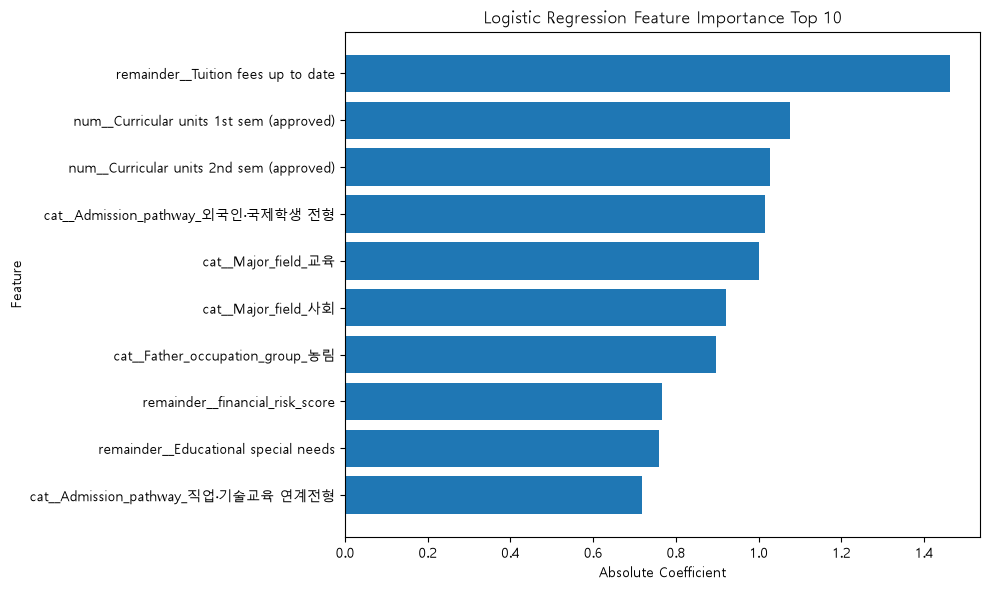

In [26]:
plt.figure(figsize=(10, 6))

plot_df = top10_logistic.sort_values("importance")

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Importance Top 10")

plt.tight_layout()
plt.show()

In [27]:
display(
    top10_logistic[
        ["feature", "coefficient", "importance", "direction"]
    ]
)

,feature,coefficient,importance,direction
0,remainder__Tuition fees up to date,-1.462300,1.462300,Dropout ↓
1,num__Curricular units 1st sem (approved),-1.076443,1.076443,Dropout ↓
2,num__Curricular units 2nd sem (approved),-1.026714,1.026714,Dropout ↓
3,cat__Admission_pathway_외국인·국제학생 전형,-1.016504,1.016504,Dropout ↓
4,cat__Major_field_교육,1.000080,1.000080,Dropout ↑
5,cat__Major_field_사회,-0.920321,0.920321,Dropout ↓
6,cat__Father_occupation_group_농림,-0.897469,0.897469,Dropout ↓
7,remainder__financial_risk_score,0.766277,0.766277,Dropout ↑
8,remainder__Educational special needs,0.758245,0.758245,Dropout ↑
9,cat__Admission_pathway_직업·기술교육 연계전형,-0.717029,0.717029,Dropout ↓
